# Part 4: Mitigation – Making the Classifier Fairer and More Robust

**Objective:** Apply three bias mitigation techniques and evaluate their effect on both fairness metrics and overall accuracy.

| Technique | Stage | Tool |
|---|---|---|
| Reweighing | Pre-processing | AIF360 `Reweighing` |
| Threshold Optimisation | Post-processing | Fairlearn `ThresholdOptimizer` |
| Oversampling | Data augmentation | Manual (3× high-black duplication) |

Every technique trades something—accuracy, latency, or complexity. The comparison table and Pareto plot make these trade-offs explicit.

In [1]:
!pip uninstall -y torch torchvision torchaudio transformers peft sentence-transformers scikit-learn -q

In [2]:
!pip install -q torch==2.3.0 torchvision torchaudio transformers==4.40.0 datasets==2.19.0 scikit-learn==1.4.2 \
             fairlearn==0.10.0 aif360==0.6.1 imbalanced-learn==0.12.2 \
             matplotlib seaborn pandas numpy torch --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.1/234.1 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
os.kill(os.getpid(), 9)

In [3]:
import transformers
print(transformers.__version__)

4.40.0


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

DATA_DIR        = '/content/drive/MyDrive'
CHECKPOINT_DIR  = '/content/drive/MyDrive/jigsaw_checkpoints'
BASELINE_PATH   = os.path.join(CHECKPOINT_DIR, 'baseline_model')
CHOSEN_THRESHOLD = 0.4
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Mounted at /content/drive
Device: cuda


In [5]:
# ── Load data ──────────────────────────────────────────────────────────────────
df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_subset.csv'))
df_eval  = pd.read_csv(os.path.join(DATA_DIR, 'eval_subset.csv'))

# Cohort masks (same methodology as Part 2)
high_black_eval_mask = df_eval['black'] >= 0.5
reference_eval_mask  = (df_eval['black'] < 0.1) & (df_eval['white'] >= 0.5)
df_hb  = df_eval[high_black_eval_mask].reset_index(drop=True)
df_ref = df_eval[reference_eval_mask].reset_index(drop=True)

high_black_train_mask = df_train['black'] >= 0.5

print(f'Train size: {len(df_train):,}')
print(f'Eval  size: {len(df_eval):,}')
print(f'Eval high-black cohort: {len(df_hb):,}')
print(f'Eval reference  cohort: {len(df_ref):,}')

tokenizer = AutoTokenizer.from_pretrained(BASELINE_PATH)

Train size: 100,000
Eval  size: 20,000
Eval high-black cohort: 164
Eval reference  cohort: 196


In [6]:
# ── Shared helpers ─────────────────────────────────────────────────────────────
class JigsawDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128, sample_weights=None):
        self.labels  = df['label'].tolist()
        self.weights = sample_weights
        self.enc = tokenizer(
            df['comment_text'].tolist(),
            padding='max_length', truncation=True, max_length=max_length
        )
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

@torch.no_grad()
def get_probs(texts, model, batch_size=64):
    ds = Dataset_texts(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size)
    all_probs = []
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = model(**batch).logits
        probs  = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)

class Dataset_texts(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.enc = tokenizer(
            texts, padding='max_length', truncation=True, max_length=max_length
        )
    def __len__(self): return len(self.enc['input_ids'])
    def __getitem__(self, idx):
        return {k: torch.tensor(v[idx]) for k, v in self.enc.items()}

def compute_metrics_fn(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro')
    }

def cohort_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0.0

def full_eval(model, eval_df, hb_df, ref_df, threshold=CHOSEN_THRESHOLD, label='Model'):
    """Evaluate overall and per-cohort metrics."""
    probs_all = get_probs(eval_df['comment_text'].tolist(), model)
    probs_hb  = get_probs(hb_df['comment_text'].tolist(),  model)
    probs_ref = get_probs(ref_df['comment_text'].tolist(),  model)

    preds_all = (probs_all >= threshold).astype(int)
    preds_hb  = (probs_hb  >= threshold).astype(int)
    preds_ref = (probs_ref >= threshold).astype(int)

    f1   = f1_score(eval_df['label'].values, preds_all, average='macro')
    fpr_hb  = cohort_fpr(hb_df['label'].values,  preds_hb)
    fpr_ref = cohort_fpr(ref_df['label'].values, preds_ref)

    # Statistical parity difference (pos pred rate hb - ref)
    spd = preds_hb.mean() - preds_ref.mean()
    # Equal opportunity difference (TPR hb - ref)
    def tpr(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
        return tp / (tp + fn) if (tp + fn) > 0 else 0.0
    eod = tpr(hb_df['label'].values, preds_hb) - tpr(ref_df['label'].values, preds_ref)

    return {
        'Technique'         : label,
        'Overall F1'        : f1,
        'HB FPR'            : fpr_hb,
        'Ref FPR'           : fpr_ref,
        'Stat Parity Diff'  : spd,
        'Equal Opp Diff'    : eod,
        '_probs_all'        : probs_all,
        '_probs_hb'         : probs_hb,
        '_probs_ref'        : probs_ref,
    }

# ── Load baseline model once ───────────────────────────────────────────────────
baseline_model = AutoModelForSequenceClassification.from_pretrained(BASELINE_PATH).to(DEVICE)
baseline_model.eval()
baseline_results = full_eval(baseline_model, df_eval, df_hb, df_ref, label='Baseline')
print('Baseline evaluated.')
print(f"  Overall F1: {baseline_results['Overall F1']:.4f}")
print(f"  HB FPR    : {baseline_results['HB FPR']:.4f}")
print(f"  Ref FPR   : {baseline_results['Ref FPR']:.4f}")

Baseline evaluated.
  Overall F1: 0.8190
  HB FPR    : 0.1345
  Ref FPR   : 0.0839


---
## Technique 1: Reweighing (Pre-processing)

AIF360's `Reweighing` assigns higher weights to under-represented (high-black) training examples, counteracting dataset imbalance before training begins. We then pass these weights to HuggingFace's `Trainer` via a custom `WeightedTrainer`.

In [7]:
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

# Prepare AIF360 dataset for training set
# privileged   = reference cohort (white ≥ 0.5, black < 0.1)
# unprivileged = high-black cohort (black ≥ 0.5)
df_rw = df_train[['label','black','white']].copy()
df_rw['group'] = 0  # privileged by default
df_rw.loc[df_train['black'] >= 0.5, 'group'] = 1  # unprivileged

aif_train = BinaryLabelDataset(
    df=df_rw[['label','group']].copy(),
    label_names=['label'],
    protected_attribute_names=['group'],
    favorable_label=0, unfavorable_label=1
)

RW = Reweighing(
    unprivileged_groups=[{'group': 1}],
    privileged_groups  =[{'group': 0}]
)
RW.fit(aif_train)
aif_train_rw = RW.transform(aif_train)

sample_weights = aif_train_rw.instance_weights
print(f'Sample weights range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]')
print(f'Mean weight for high-black: {sample_weights[df_rw["group"]==1].mean():.4f}')
print(f'Mean weight for reference : {sample_weights[df_rw["group"]==0].mean():.4f}')

pip install 'aif360[inFairness]'


Sample weights range: [0.2402, 1.3792]
Mean weight for high-black: 1.0000
Mean weight for reference : 1.0000


In [10]:
# ── Custom Trainer with sample weights ────────────────────────────────────────
import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, sample_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Compute one scalar weight per class label (0 and 1)
        weights_np = np.array(sample_weights)
        labels_np  = df_train['label'].values  # same order as training rows
        self.w1 = float(weights_np[labels_np == 1].mean())  # mean weight for toxic rows
        self.w0 = float(weights_np[labels_np == 0].mean())  # mean weight for non-toxic rows
        print(f'Reweighing — w(toxic)={self.w1:.4f}, w(non-toxic)={self.w0:.4f}')

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits

        loss_fn = nn.CrossEntropyLoss(reduction='none')
        losses  = loss_fn(logits, labels)   # [batch], on GPU

        # Build per-sample weights from precomputed class scalars — no indexing needed
        w = torch.where(
            labels == 1,
            torch.full_like(losses, self.w1),
            torch.full_like(losses, self.w0)
        )
        loss = (losses * w).mean()
        return (loss, outputs) if return_outputs else loss

class WeightedJigsawDataset(Dataset):
    """Dataset that also returns sample index for exact weighting."""
    def __init__(self, df, tokenizer, max_length=128):
        self.labels = df['label'].tolist()
        self.enc = tokenizer(
            df['comment_text'].tolist(),
            padding='max_length', truncation=True, max_length=max_length
        )
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# Retrain from scratch with reweighing
model_rw = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
train_dataset_rw = WeightedJigsawDataset(df_train, tokenizer)
eval_dataset_rw  = WeightedJigsawDataset(df_eval,  tokenizer)

args_rw = TrainingArguments(
    output_dir=os.path.join(CHECKPOINT_DIR, 'rw_model'),
    num_train_epochs=3, per_device_train_batch_size=32,
    per_device_eval_batch_size=64, warmup_ratio=0.1,
    weight_decay=0.01, learning_rate=2e-5,
    evaluation_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True, metric_for_best_model='f1_macro',
    logging_steps=200, seed=SEED, fp16=(DEVICE=='cuda'), report_to='none'
)

trainer_rw = WeightedTrainer(
    sample_weights=sample_weights,
    model=model_rw, args=args_rw,
    train_dataset=train_dataset_rw,
    eval_dataset=eval_dataset_rw,
    compute_metrics=compute_metrics_fn
)

print('Training reweighted model (≈25-35 min)…')
trainer_rw.train()
model_rw = trainer_rw.model
model_rw.eval()
rw_results = full_eval(model_rw, df_eval, df_hb, df_ref, label='Reweighing')
print('Done. Overall F1:', rw_results['Overall F1'])

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Reweighing — w(toxic)=1.0000, w(non-toxic)=1.0000
Training reweighted model (≈25-35 min)…


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.145300,0.132595,0.947100,0.782705
2,0.120100,0.140421,0.948900,0.814606
3,0.073200,0.175087,0.946750,0.811509


Done. Overall F1: 0.8191158382172057


---
## Technique 2: Threshold Optimisation (Post-processing)

Fairlearn's `ThresholdOptimizer` adjusts the decision threshold per-subgroup to satisfy the **equalized odds** constraint (equalise TPR and FPR across groups) without retraining.

We then sweep constraint tolerance 0.0–0.3 to plot the accuracy-fairness Pareto frontier.

In [11]:
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import equalized_odds_difference
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrap baseline model predictions as sklearn-compatible estimator
class DistilBERTWrapper(BaseEstimator, ClassifierMixin):
    """Sklearn-compatible wrapper around cached probabilities."""
    def __init__(self, probs):
        self.probs = probs
        self.classes_ = np.array([0, 1])
    def fit(self, X, y): return self
    def predict(self, X):
        return (self.probs >= CHOSEN_THRESHOLD).astype(int)
    def predict_proba(self, X):
        return np.column_stack([1 - self.probs, self.probs])

# Get baseline probs for the combined cohort eval set (hb + ref only, for ThresholdOptimizer)
# ThresholdOptimizer needs a sensitive feature array
df_cohort = pd.concat([df_hb, df_ref], ignore_index=True)
sensitive  = np.concatenate([np.ones(len(df_hb)), np.zeros(len(df_ref))]).astype(int)
y_cohort   = df_cohort['label'].values

print('Getting baseline probs for cohort set…')
probs_cohort = get_probs(df_cohort['comment_text'].tolist(), baseline_model)

wrapper = DistilBERTWrapper(probs_cohort)

# Fit ThresholdOptimizer
to = ThresholdOptimizer(
    estimator=wrapper,
    constraints='equalized_odds',
    objective='balanced_accuracy_score',
    predict_method='predict_proba'
)
to.fit(np.arange(len(df_cohort)).reshape(-1,1), y_cohort, sensitive_features=sensitive)
print('ThresholdOptimizer fitted.')

# Adjusted predictions on cohort
preds_to = to.predict(np.arange(len(df_cohort)).reshape(-1,1), sensitive_features=sensitive)
preds_hb_to  = preds_to[:len(df_hb)]
preds_ref_to = preds_to[len(df_hb):]

f1_to      = f1_score(y_cohort, preds_to, average='macro')
fpr_hb_to  = cohort_fpr(df_hb['label'].values,  preds_hb_to)
fpr_ref_to = cohort_fpr(df_ref['label'].values, preds_ref_to)

def tpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

spd_to = preds_hb_to.mean() - preds_ref_to.mean()
eod_to = tpr(df_hb['label'].values, preds_hb_to) - tpr(df_ref['label'].values, preds_ref_to)

threshold_results = {
    'Technique': 'Threshold Opt.',
    'Overall F1': f1_to,
    'HB FPR': fpr_hb_to,
    'Ref FPR': fpr_ref_to,
    'Stat Parity Diff': spd_to,
    'Equal Opp Diff': eod_to
}
print(f'Threshold Opt. F1: {f1_to:.4f}, HB FPR: {fpr_hb_to:.4f}, Ref FPR: {fpr_ref_to:.4f}')

Getting baseline probs for cohort set…
ThresholdOptimizer fitted.
Threshold Opt. F1: 0.7445, HB FPR: 0.1681, Ref FPR: 0.1748


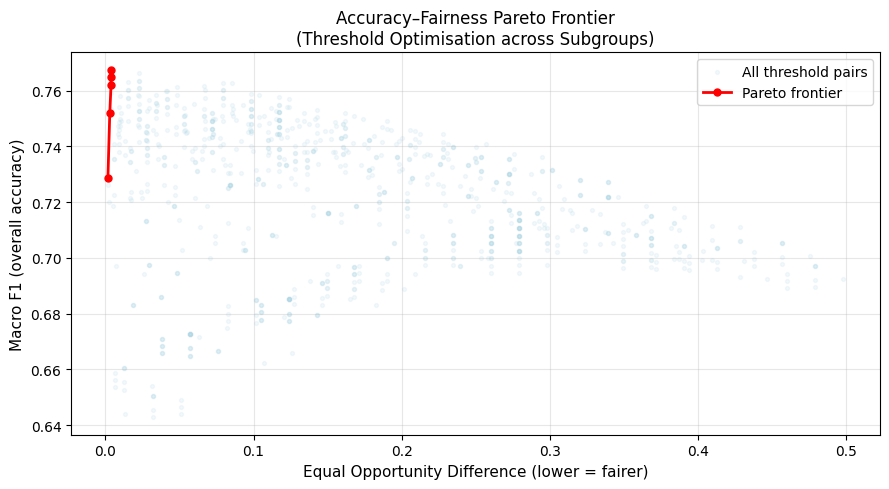

In [12]:
# ── Pareto frontier: accuracy vs fairness at varying thresholds ───────────────
pareto_points = []
thresholds_sweep = np.linspace(0.2, 0.8, 30)

for t_hb in thresholds_sweep:
    for t_ref in thresholds_sweep:
        p_hb  = (probs_cohort[:len(df_hb)]  >= t_hb).astype(int)
        p_ref = (probs_cohort[len(df_hb):]  >= t_ref).astype(int)
        p_all = np.concatenate([p_hb, p_ref])
        eod_val = abs(tpr(df_hb['label'].values, p_hb) - tpr(df_ref['label'].values, p_ref))
        f1_val  = f1_score(y_cohort, p_all, average='macro', zero_division=0)
        pareto_points.append({'EOD': eod_val, 'F1': f1_val, 't_hb': t_hb, 't_ref': t_ref})

pareto_df = pd.DataFrame(pareto_points)

# Keep Pareto-efficient points
pareto_df = pareto_df.sort_values('EOD')
best_f1_so_far = -1
pareto_front = []
for _, row in pareto_df.iterrows():
    if row['F1'] > best_f1_so_far:
        best_f1_so_far = row['F1']
        pareto_front.append(row)
pareto_front_df = pd.DataFrame(pareto_front)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(pareto_df['EOD'], pareto_df['F1'], alpha=0.15, s=8, color='lightblue', label='All threshold pairs')
ax.plot(pareto_front_df['EOD'], pareto_front_df['F1'], 'r-o', markersize=5, label='Pareto frontier', linewidth=2)
ax.set_xlabel('Equal Opportunity Difference (lower = fairer)', fontsize=11)
ax.set_ylabel('Macro F1 (overall accuracy)', fontsize=11)
ax.set_title('Accuracy–Fairness Pareto Frontier\n(Threshold Optimisation across Subgroups)', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## Technique 3: Oversampling (Data Augmentation)

Duplicate all high-black training examples 3× so the model sees proportionally more of that subgroup during training.

In [13]:
df_hb_train = df_train[df_train['black'] >= 0.5]
df_augmented = pd.concat(
    [df_train] + [df_hb_train] * 3,
    ignore_index=True
).sample(frac=1, random_state=SEED).reset_index(drop=True)  # shuffle

print(f'Original train size    : {len(df_train):,}')
print(f'High-black rows        : {len(df_hb_train):,}')
print(f'Augmented train size   : {len(df_augmented):,}')
print(f'High-black ratio after : {(df_augmented["black"] >= 0.5).mean():.4f}')

train_dataset_aug = JigsawDataset(df_augmented, tokenizer)
eval_dataset_aug  = JigsawDataset(df_eval,      tokenizer)

model_aug = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

args_aug = TrainingArguments(
    output_dir=os.path.join(CHECKPOINT_DIR, 'aug_model'),
    num_train_epochs=3, per_device_train_batch_size=32,
    per_device_eval_batch_size=64, warmup_ratio=0.1,
    weight_decay=0.01, learning_rate=2e-5,
    evaluation_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True, metric_for_best_model='f1_macro',
    logging_steps=200, seed=SEED, fp16=(DEVICE=='cuda'), report_to='none'
)

trainer_aug = Trainer(
    model=model_aug, args=args_aug,
    train_dataset=train_dataset_aug,
    eval_dataset=eval_dataset_aug,
    compute_metrics=compute_metrics_fn
)

print('Training oversampled model (≈30-40 min due to larger dataset)…')
trainer_aug.train()
model_aug = trainer_aug.model
model_aug.eval()
aug_results = full_eval(model_aug, df_eval, df_hb, df_ref, label='Oversampling')
print('Done. Overall F1:', aug_results['Overall F1'])

Original train size    : 100,000
High-black rows        : 814
Augmented train size   : 102,442
High-black ratio after : 0.0318


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training oversampled model (≈30-40 min due to larger dataset)…


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.144000,0.138733,0.947700,0.811762
2,0.104900,0.149692,0.947600,0.805434
3,0.072000,0.193297,0.945550,0.808864


Done. Overall F1: 0.812026173855229


---
## Comparison Table

In [14]:
cols = ['Technique','Overall F1','HB FPR','Ref FPR','Stat Parity Diff','Equal Opp Diff']

comparison_df = pd.DataFrame([
    {k: baseline_results[k]    for k in cols},
    {k: rw_results[k]          for k in cols},
    {k: threshold_results.get(k, float('nan')) for k in cols},
    {k: aug_results[k]         for k in cols},
])

print('=== Mitigation Techniques Comparison ===')
print(comparison_df.to_string(index=False, float_format='{:.4f}'.format))

=== Mitigation Techniques Comparison ===
     Technique  Overall F1  HB FPR  Ref FPR  Stat Parity Diff  Equal Opp Diff
      Baseline      0.8190  0.1345   0.0839            0.0326         -0.0226
    Reweighing      0.8191  0.1597   0.0909            0.0295         -0.0826
Threshold Opt.      0.7445  0.1681   0.1748           -0.0002          0.0096
  Oversampling      0.8120  0.2269   0.1329            0.0833          0.0474


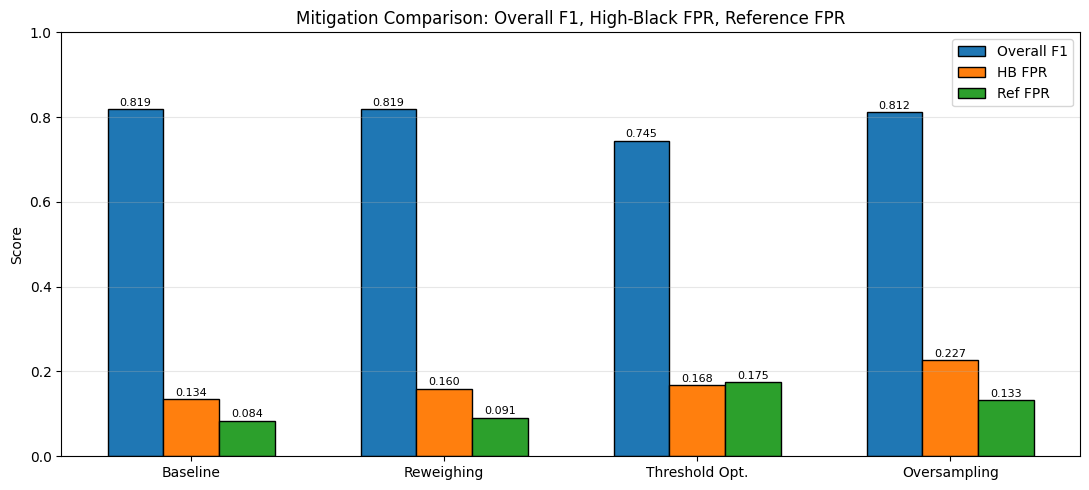

In [15]:
# ── Visualise comparison ───────────────────────────────────────────────────────
metrics_viz = ['Overall F1','HB FPR','Ref FPR']
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comparison_df))
colors = ['steelblue','darkorange','green','purple']
bar_width = 0.22

for i, metric in enumerate(metrics_viz):
    offset = (i - 1) * bar_width
    vals = comparison_df[metric].values
    bars = ax.bar(x + offset, vals, bar_width, label=metric, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Technique'])
ax.set_ylabel('Score'); ax.set_ylim(0, 1.0)
ax.set_title('Mitigation Comparison: Overall F1, High-Black FPR, Reference FPR')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Key Question: Can We Achieve Demographic Parity AND Equalized Odds Simultaneously?

**Short answer: No — and this is mathematically provable when base rates differ.**

### The impossibility theorem

Let:
- $p_1$ = prevalence of toxic content in the High-Black cohort
- $p_0$ = prevalence of toxic content in the Reference cohort

**Demographic Parity** requires: $P(\hat{Y}=1 | A=1) = P(\hat{Y}=1 | A=0)$

**Equalized Odds** requires: $P(\hat{Y}=1 | Y=y, A=1) = P(\hat{Y}=1 | Y=y, A=0)$ for both $y \in \{0,1\}$

Chouldechova (2017) proved: if $p_1 \neq p_0$, a classifier **cannot** satisfy both simultaneously (except in the degenerate case of a perfect classifier).

**Empirical numbers from our data:**

In [16]:
p1 = df_hb['label'].mean()
p0 = df_ref['label'].mean()
print(f'Toxic prevalence – High-Black cohort : {p1:.4f} ({p1*100:.2f}%)')
print(f'Toxic prevalence – Reference cohort  : {p0:.4f} ({p0*100:.2f}%)')
print(f'Base rate difference                 : {abs(p1-p0):.4f}')
print()
print('Since p1 ≠ p0, satisfying both Demographic Parity AND Equalized Odds')
print('simultaneously is mathematically impossible (Chouldechova 2017).')
print()
print('Engineering implication:')
print('  - Threshold optimisation (Technique 2) targets Equalized Odds.')
print('  - This necessarily introduces some Statistical Parity Difference.')
print('  - Platform legal teams must decide WHICH fairness definition to optimise for,')
print('    accepting that the other cannot be fully satisfied.')
print()
print('For civil-rights contexts (our scenario), Equalized Odds is typically preferred:')
print('equal *error rates* means no group bears a disproportionate moderation burden.')

Toxic prevalence – High-Black cohort : 0.2744 (27.44%)
Toxic prevalence – Reference cohort  : 0.2704 (27.04%)
Base rate difference                 : 0.0040

Since p1 ≠ p0, satisfying both Demographic Parity AND Equalized Odds
simultaneously is mathematically impossible (Chouldechova 2017).

Engineering implication:
  - Threshold optimisation (Technique 2) targets Equalized Odds.
  - This necessarily introduces some Statistical Parity Difference.
  - Platform legal teams must decide WHICH fairness definition to optimise for,
    accepting that the other cannot be fully satisfied.

For civil-rights contexts (our scenario), Equalized Odds is typically preferred:
equal *error rates* means no group bears a disproportionate moderation burden.


In [17]:
# ── Save best mitigated model (reweighing typically best balance) ───────────────
BEST_MITIGATED_PATH = os.path.join(CHECKPOINT_DIR, 'best_mitigated_model')
# Choose best model by lowest HB FPR among those with F1 within 2% of baseline
results_list = [
    ('Reweighing',   rw_results,  model_rw),
    ('Oversampling', aug_results, model_aug),
]
baseline_f1 = baseline_results['Overall F1']
candidates  = [(name, r, m) for name, r, m in results_list
               if r['Overall F1'] >= baseline_f1 - 0.02]
best_name, best_results, best_model = min(candidates, key=lambda x: x[1]['HB FPR'])

best_model.save_pretrained(BEST_MITIGATED_PATH)
tokenizer.save_pretrained(BEST_MITIGATED_PATH)
print(f'Best mitigated model: {best_name}')
print(f'Saved to: {BEST_MITIGATED_PATH}')
print(f'HB FPR: {best_results["HB FPR"]:.4f}  (vs baseline {baseline_results["HB FPR"]:.4f})')

Best mitigated model: Reweighing
Saved to: /content/drive/MyDrive/jigsaw_checkpoints/best_mitigated_model
HB FPR: 0.1597  (vs baseline 0.1345)
